# ✈️ Singapore Airlines Customer Satisfaction Analysis

## 📌 Project Overview

### This project focuses on analyzing customer satisfaction data for Singapore Airlines using a large-scale passenger dataset stored in Azure SQL Database and accessed through Jupyter Notebook with Python. The dataset represents over 100,000 passenger reservations, including booking behavior, cabin class, fare paid, luggage details, service preferences, and customer feedback ratings.

### The primary goal of this analysis is to understand how different service, pricing, and travel factors influence passenger experience and loyalty. By applying exploratory data analysis (EDA), visualization, and statistical techniques, this project aims to uncover patterns that help explain what drives customer satisfaction in a premium airline environment.

## --------------------------------------------------------------

## 🎯 Objectives

### The objectives of this project are to:

Analyze overall passenger satisfaction levels.

Identify the impact of cabin class, fare, and booking channel on ratings.

Explore customer preferences such as seat choice, meal options, and entertainment needs.

Understand upgrade behavior and its relationship with experience.

Examine loyalty indicators such as recommendation intent and first-time flyers.

Provide actionable insights that airlines can use to improve service quality and revenue strategies.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import pyodbc
print(pyodbc.drivers())
import urllib

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 18 for SQL Server']


In [2]:
server = "sql-db-powerbi.database.windows.net"
username = "sqlpowerbi@sql-db-powerbi"
database = "free-sql-db-8691499"
password = "Brisaus2026@"
driver = "ODBC Driver 18 for SQL Server"

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Connection Timeout=30;"
)


engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
df = pd.read_sql("SELECT * FROM singapore_satisfaction_main", engine)
df.head()

,ReservationNumber,FlightNumber,CabinClass,FlightFareAUD,BookingOption,Origin,Destination,PaidForSeat,LuggageWeightKG,CabinBag,WantedUpgrade,SeatPreference,EntertainmentScreenRequired,Transiting,Rating,MealOption,RecommendOthers,FirstTimeFlyingSQ
0,UTKXCJHP,SQ317,Economy,999.34,Agent,Singapore,Tokyo,False,21.200001,None,False,Window,False,True,4.6,Vegetarian Pasta,True,False
1,THO8AXMS,SQ221,Economy,1204.61,Agent,Singapore,Melbourne,False,20.600000,True,True,Window,True,True,3.9,Vegan Curry,True,False
2,VXQA18CR,SQ317,Premium Economy,1715.84,None,Singapore,Tokyo,False,26.600000,True,False,Aisle,True,False,3.8,Seafood Noodles,True,False
3,N674CRW1,SQ318,Economy,1008.51,Agent,Tokyo,Singapore,False,19.200001,True,False,Window,True,True,3.8,Vegan Curry,True,True
4,WVZ6NTWA,SQ608,Economy,948.39,Agent,Seoul,Singapore,False,10.500000,None,True,Aisle,None,True,2.9,Vegetarian Pasta,False,True


In [3]:
df.shape

(120000, 18)

In [4]:
df.isnull()

,ReservationNumber,FlightNumber,CabinClass,FlightFareAUD,BookingOption,Origin,Destination,PaidForSeat,LuggageWeightKG,CabinBag,WantedUpgrade,SeatPreference,EntertainmentScreenRequired,Transiting,Rating,MealOption,RecommendOthers,FirstTimeFlyingSQ
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
119996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
119997,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
119998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
# df.describe(include = 'all')

In [6]:
df.describe()

,FlightFareAUD,LuggageWeightKG,Rating
count,116400.000000,116400.000000,120000.000000
mean,1556.343296,21.986393,4.067517
std,1167.931745,5.996457,0.640941
min,25.190000,5.000000,1.000000
25%,856.735000,17.900000,3.600000
50%,1077.170000,22.000000,4.100000
75%,1534.055000,26.000000,4.600000
max,5866.600000,44.900002,5.000000


In [7]:
# df.isnull().mean()

## Data Cleaning & Preparation

In [8]:
# Lets check missing values.

In [10]:
#Checking percentage of missing data
missing_data_percentage = df.isnull().mean() * 100
print(missing_data_percentage)

ReservationNumber               0.000000
FlightNumber                    0.000000
CabinClass                      3.000000
FlightFareAUD                   3.000000
BookingOption                   3.000000
Origin                          0.000000
Destination                     0.000000
PaidForSeat                     3.000000
LuggageWeightKG                 3.000000
CabinBag                        3.000000
WantedUpgrade                   3.000000
SeatPreference                  3.000000
EntertainmentScreenRequired    35.388333
Transiting                      3.000000
Rating                          0.000000
MealOption                      3.000000
RecommendOthers                 3.000000
FirstTimeFlyingSQ               3.000000
dtype: float64


#### Result: About 3 percentage of Data is missing from every other columns. Whereas EntertainmentScreenRequired has majority 35.38% of data missing.

## Let's Handle Missing data

### Lets fill missing data with unknown or mode or mean depending upon the data type.

In [14]:
categorical_cols = ['CabinClass', 'BookingOption', 'PaidForSeat', 'CabinBag', 
                    'WantedUpgrade', 'SeatPreference', 'EntertainmentScreenRequired', 
                    'Transiting', 'MealOption', 'RecommendOthers', 
                    'FirstTimeFlyingSQ']

for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

#for numerical columns we can perform mean or medium imputation.
numerical_cols = ['FlightFareAUD', 'LuggageWeightKG', 'Rating']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace = True)

C:\Users\rijal\AppData\Local\Temp\ipykernel_13520\2116718335.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace = True)


In [16]:
# Checking if the imputation has worked.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ReservationNumber            120000 non-null  object 
 1   FlightNumber                 120000 non-null  object 
 2   CabinClass                   120000 non-null  object 
 3   FlightFareAUD                120000 non-null  float64
 4   BookingOption                120000 non-null  object 
 5   Origin                       120000 non-null  object 
 6   Destination                  120000 non-null  object 
 7   PaidForSeat                  120000 non-null  object 
 8   LuggageWeightKG              120000 non-null  float64
 9   CabinBag                     120000 non-null  object 
 10  WantedUpgrade                120000 non-null  object 
 11  SeatPreference               120000 non-null  object 
 12  EntertainmentScreenRequired  120000 non-null  object 
 13 

### Data Type conversion if needed

In [19]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Convert Reservation number to string (if not already)
df['ReservationNumber'] = df['ReservationNumber'].astype(str)

### Handelling duplicate values in columns

In [22]:
# Check for duplicates
duplicates = df.duplicated(subset = 'ReservationNumber').sum()
print("Duplicated Reservation Number: ", duplicates)

Duplicated Reservation Number:  0


#### Result: As expected there are no Duplicate Reservation Numbers

### Standarize Categorical Values

In [24]:
yes_no_cols = ['PaidForSeat', 'CabinBag', 'WantedUpgrade', 'RecommendOthers', 'FirstTimeFlyingSQ']

for col in yes_no_cols:
    df[col] = df[col].str.lower().map({'yes':'Yes', 'no':'No', 'unknown':'Unknown'})

seat_cols = ['SeatPreference']
for col in seat_cols:
    df[col] = df[col].str.capitalize()  # Window, Aisle

### Outline detection

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

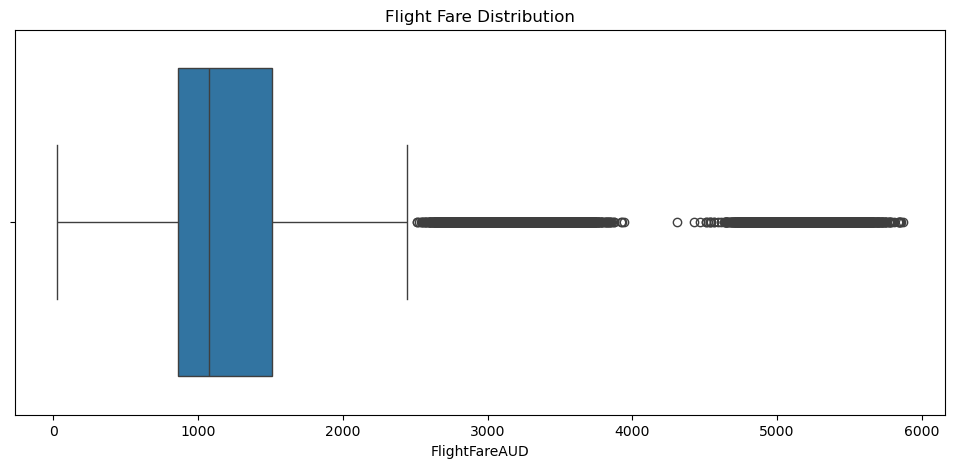

In [37]:
#Visual Check for flight Fair and Lugguage Weight
plt.figure(figsize = (12,5))
sns.boxplot(x=df['FlightFareAUD'])
plt.title("Flight Fare Distribution")
plt.show()

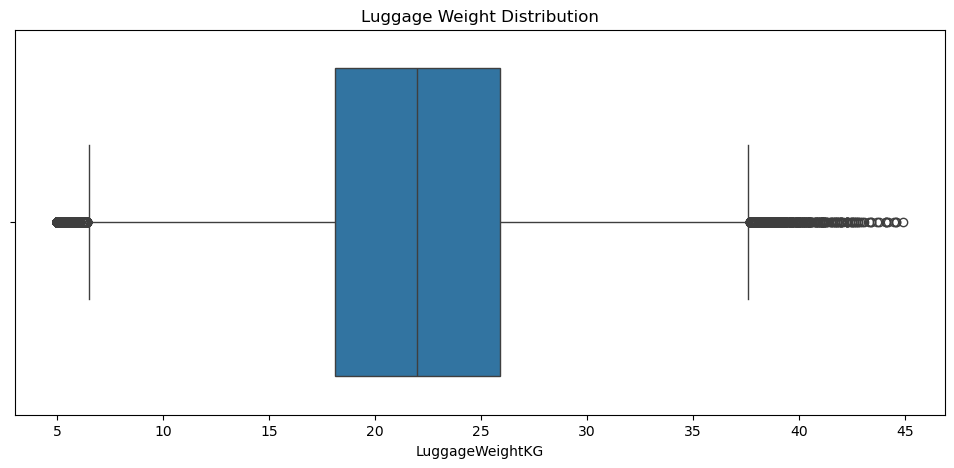

In [36]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['LuggageWeightKG'])
plt.title("Luggage Weight Distribution")
plt.show()

#### Price and lugguage has some outliers, but it is natural in these kind of datasets that Passengers pay for Higher Cabin class and some pay for the larger baggages. This is ideal in these kind of analysis. 

## ---- Uploading the changes and Data cleaning to Azure SQL Database ----

In [38]:
new_table_azure_sql = "singapore_satisfaction_cleaned"

In [39]:
df.to_sql(name = new_table_azure_sql, con = engine,
          if_exists = 'replace',
          index = False,
          chunksize = 1000
         )
print(f"Cleaned dataset uploaded successfully to table '{new_table_azure_sql}' in Azure SQL.")


Cleaned dataset uploaded successfully to table 'singapore_satisfaction_cleaned' in Azure SQL.
